In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_analysis=pd.read_csv('Data/data.csv')

In [76]:
#data cleaning and preprocessing

# Remove entries which do not have age, jersey number and nationality 

df_analysis = df_analysis[df_analysis['Nationality'].notna()]
df_analysis = df_analysis[df_analysis['Age'].notna()]
df_analysis = df_analysis[df_analysis['Jersey Number'].notna()]
# Fill missing values with 0 for numerical columns and mode for categorical columns 
df_analysis[['Goals per match', 'Headed goals', 'Goals with right foot', 'Goals with left foot','Penalties scored','Freekicks scored','Shots','Shots on target', 'Shooting accuracy %','Hit woodwork','Big chances missed','Clean sheets','Goals conceded','Tackles','Tackle success %','Offsides']] = df_analysis[['Goals per match', 'Headed goals', 'Goals with right foot', 'Goals with left foot', 'Penalties scored','Freekicks scored', 'Shots', 'Shots on target', 'Shooting accuracy %','Hit woodwork','Big chances missed','Clean sheets','Goals conceded','Tackles','Tackle success %','Offsides']].fillna(0)
df_analysis['Nationality']= df_analysis['Nationality'].fillna(df_analysis['Nationality'].mode()[0])
df_analysis['Age']= df_analysis['Age'].fillna(df_analysis['Age'].median())
# cleaning the percentage sign
df_analysis['Cross accuracy %'] = df_analysis['Cross accuracy %'].str.replace(r'%', '').astype(float)
df_analysis['Shooting accuracy %'] = df_analysis['Shooting accuracy %'].str.replace(r'%', '').astype(float)
df_analysis['Tackle success %'] = df_analysis['Tackle success %'].str.replace(r'%', '').astype(float)


print(df_analysis['Name'].duplicated().sum()) # check for duplicate entries(should be 0 )


# check if there are any invalid values in the percentage columns (values less than 0 or greater than 100)

for col in ['Shooting accuracy %','Tackle success %','Cross accuracy %']:
    if col in df_analysis.columns:
        invalid_values = df_analysis[(df_analysis[col] < 0) | (df_analysis[col] > 100)][col]
        print(f"{col} - number of invalid values: {len(invalid_values)}")
        if len(invalid_values) > 0:
            print(invalid_values)

0
Shooting accuracy % - number of invalid values: 0
Tackle success % - number of invalid values: 0
Cross accuracy % - number of invalid values: 0


In [77]:

#data cleaning for forwards
#filtering forwards with at least 1 appearance
forwards = df_analysis[df_analysis['Position'].str.contains('Forward')&(df_analysis['Appearances'] > 0)]
# Drop the specified columns from the forwards DataFrame
cols_to_drop = [
    'Clean sheets', 'Goals conceded', 'Tackles', 'Tackle success %', 
    'Last man tackles', 'Blocked shots', 'Interceptions', 'Clearances', 
    'Headed Clearance', 'Clearances off line', 'Own goals', 'Saves', 
    'Penalties saved', 'Punches', 'High Claims', 'Catches', 'Sweeper clearances', 'Throw outs', 'Goal Kicks','Through balls'	,'Accurate long balls'
]

forwards = forwards.drop(columns=cols_to_drop)

#feature engineering
 
forwards['shot_conversion'] = np.where(
    forwards['Shots'] > 0,
    forwards['Goals'] / forwards['Shots'],
    np.nan
)

forwards['shots_per_match'] =forwards['Shots'] / forwards['Appearances']

#goal per shot on target
forwards['goals_per_shot_on_target'] = np.where(
    forwards['Shots on target'] > 0,
    forwards['Goals'] / forwards['Shots on target'],
    np.nan
)
forwards['xG_estimated'] = (forwards['Shots on target'] * 0.3 +(forwards['Shots'] - forwards['Shots on target']) * 0.05 +forwards['Big chances missed'] * 0.4
)
forwards['xG_diff'] = forwards['Goals'] - forwards['xG_estimated']
bins = [15, 20, 25, 30, 35, 40]
labels = ['15-20', '21-25', '26-30', '31-35', '36-40']

forwards['Age Group'] = pd.cut(forwards['Age'], bins=[15, 20, 25, 30, 35], labels=['15-20', '21-25', '26-30', '31-35'])
forwards.describe()


,Jersey Number,Age,Appearances,Wins,Losses,Goals,Goals per match,Headed goals,Goals with right foot,Goals with left foot,...,Cross accuracy %,Yellow cards,Red cards,Fouls,Offsides,shot_conversion,shots_per_match,goals_per_shot_on_target,xG_estimated,xG_diff
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,4.000000,100.000000,100.000000,100.000000,100.000000,97.000000,100.000000,94.000000,100.000000,100.000000
mean,16.450000,25.920000,85.020000,35.900000,29.630000,23.610000,1.009400,3.880000,13.080000,6.530000,...,24.000000,7.060000,0.370000,75.890000,37.120000,0.124945,1.545836,0.324715,32.450000,-8.840000
std,9.650849,4.011801,78.962973,41.427434,27.170489,31.689113,2.936146,6.204072,20.017507,11.127775,...,6.055301,8.754589,0.733815,86.828043,48.286242,0.068579,0.809597,0.152144,39.158474,10.615081
min,4.000000,18.000000,1.000000,0.000000,0.000000,0.000000,0.030000,0.000000,0.000000,0.000000,...,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-54.150000
25%,9.000000,23.000000,25.750000,7.000000,10.750000,3.000000,0.147500,0.000000,1.000000,0.000000,...,20.750000,1.000000,0.000000,13.000000,4.000000,0.076923,0.914025,0.251293,4.237500,-13.100000
50%,13.000000,26.000000,58.500000,17.000000,19.000000,9.500000,0.225000,1.000000,5.000000,2.000000,...,21.500000,3.500000,0.000000,37.000000,15.500000,0.133333,1.505805,0.333333,13.400000,-5.075000
75%,21.000000,29.000000,123.750000,46.000000,46.000000,38.250000,0.352500,5.000000,16.250000,7.000000,...,24.750000,11.000000,0.250000,114.750000,52.000000,0.173719,2.109570,0.417691,51.012500,-0.687500
max,58.000000,34.000000,346.000000,177.000000,143.000000,180.000000,19.000000,31.000000,127.000000,63.000000,...,33.000000,35.000000,3.000000,395.000000,203.000000,0.333333,3.787072,0.750000,202.950000,2.050000


In [78]:
def the_top_player(df, column):
    top_value = df[column].max()
    players = df[df[column] == top_value]
    return list(zip(players['Name'], players[column]))

def the_bottom_player(df, column):
    bottom_value = df[column].min()
    players = df[df[column] == bottom_value]
    return list(zip(players['Name'], players[column]))

In [79]:
#Descriptive analysis of forwards

#1-the best players for forwards 
def the_best_forward_players():
    #the top goals
    top_goals = the_top_player(forwards, 'Goals')
    #Player with Fewest Offsides
    bottom_offside = the_bottom_player(forwards, 'Offsides')
    #the Top Shot Conversion Rate
    top_shot_conversion = the_top_player(forwards, 'shot_conversion')
    #the Top Shooting Accuracy
    top_shooting_accuracy = the_top_player(forwards, 'Shooting accuracy %')
    #the Top goals per shot on target
    top_goals_per_match = the_top_player(forwards, 'goals_per_shot_on_target')
    #the tope right foot scorrer
    top_right_foot_scorrer = the_top_player(forwards, 'Goals with right foot')
    #the top left foot scorrer
    top_left_foot_scorrer = the_top_player(forwards, 'Goals with left foot')
    #the top assester
    top_assister = the_top_player(forwards, 'Assists')
    #the top shots per match
    top_shots_per_match = the_top_player(forwards, 'shots_per_match')
    #the top goals per shot on target
    top_goals_per_shot_on_target = the_top_player(forwards, 'goals_per_shot_on_target')
    print(
        f"Top Goals: {top_goals}\n"
        f"Top Assister: {top_assister}\n"
        f"Fewest Offsides: {bottom_offside}\n"
        f"Top Shot Conversion: {top_shot_conversion}\n"
        f"Top Shooting Accuracy: {top_shooting_accuracy}\n"
        f"Top Goals per Match: {top_goals_per_match}\n"
        f"Top Right Foot Scorer: {top_right_foot_scorrer}\n"
        f"Top Left Foot Scorer: {top_left_foot_scorrer}\n"
        f"Top Shots per Match: {top_shots_per_match}\n"
        f"Top Goals per Shot on Target: {top_goals_per_shot_on_target}\n"
    )

the_best_forward_players()


Top Goals: [('Sergio Agüero', 180)]
Top Assister: [('Theo Walcott', 51)]
Fewest Offsides: [('Brandon Pierrick', 0.0), ('Tyler Roberts', 0.0), ('Takumi Minamino', 0.0), ('Ben Woodburn', 0.0), ('Ferran Torres', 0.0), ('Steven Bergwijn', 0.0), ('Matheus Pereira', 0.0), ('Xande Silva', 0.0), ('Fábio Silva', 0.0)]
Top Shot Conversion: [('Steven Bergwijn', 0.3333333333333333)]
Top Shooting Accuracy: [('Matej Vydra', 54.0), ('Gabriel Jesus', 54.0)]
Top Goals per Match: [('Ivan Cavaleiro', 0.75), ('Steven Bergwijn', 0.75)]
Top Right Foot Scorer: [('Sergio Agüero', 127.0)]
Top Left Foot Scorer: [('Mohamed Salah', 63.0)]
Top Shots per Match: [('Sergio Agüero', 3.7870722433460076)]
Top Goals per Shot on Target: [('Ivan Cavaleiro', 0.75), ('Steven Bergwijn', 0.75)]



In [ ]:
#bar plots for the top 8 clubs by goals, top scorer in each club, top 8 clubs by assists and top 8 players by assists
#the grouping 
club_goals = forwards.groupby('Club')['Goals'].sum().sort_values(ascending=False).head(8)
top_scorer_per_club = forwards.loc[forwards.groupby('Club')['Goals'].idxmax()][['Club', 'Name', 'Goals']]
top_scorer_per_club = top_scorer_per_club.sort_values(by='Goals', ascending=False).head(8)
club_assists = forwards.groupby('Club')['Assists'].sum().sort_values(ascending=False).head(8)
top_assist_players = forwards.sort_values(by='Assists', ascending=False).head(8)

plt.figure(figsize=(18, 10))

# plot 1
plt.subplot(2, 2, 1)
ax1 = sns.barplot(x=club_goals.index, y=club_goals.values)
plt.title('Top Clubs by Goals')
plt.xticks(rotation=45)

for i, v in enumerate(club_goals.values):
    ax1.text(i, v, str(v), ha='center', va='bottom')

# plot 2
plt.subplot(2, 2, 2)
ax2 = sns.barplot(x=top_scorer_per_club['Name'], y=top_scorer_per_club['Goals'])
plt.title('Top Scorer in Each Club')
plt.xticks(rotation=45)

for i, v in enumerate(top_scorer_per_club['Goals']):
    ax2.text(i, v, str(v), ha='center', va='bottom')

#plot 3 
plt.subplot(2, 2, 3)
ax3 = sns.barplot(x=club_assists.index, y=club_assists.values)
plt.title('Top Clubs by Assists')
plt.xticks(rotation=45)

for i, v in enumerate(club_assists.values):
    ax3.text(i, v, str(v), ha='center', va='bottom')

#plot 4   
plt.subplot(2, 2, 4)
ax4 = sns.barplot(x=top_assist_players['Name'], y=top_assist_players['Assists'])
plt.title('Top Players by Assists')
plt.xticks(rotation=45)

for i, v in enumerate(top_assist_players['Assists']):
    ax4.text(i, v, str(v), ha='center', va='bottom')

plt.tight_layout()
plt.show()


KeyboardInterrupt: 

<Figure size 1800x1000 with 0 Axes>

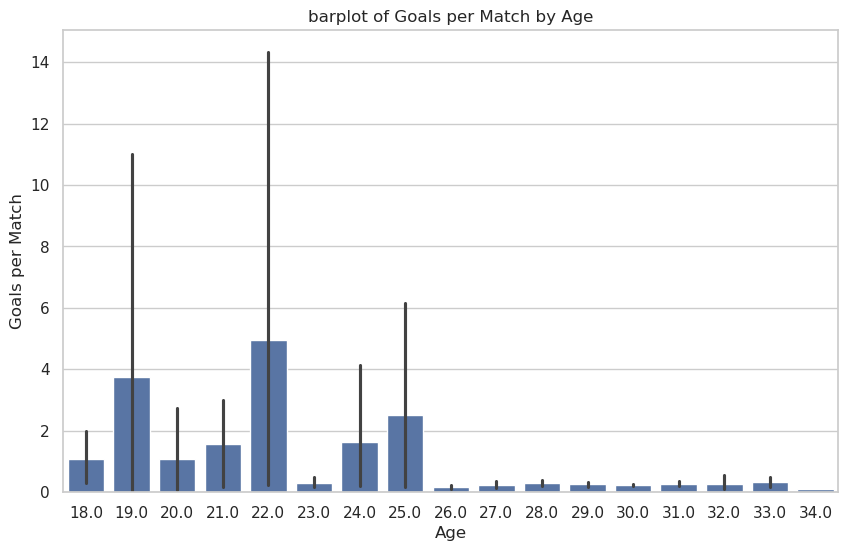

In [81]:
#2-goal per match distribution by aga
plt.figure(figsize=(10, 6))
sns.barplot(x='Age', y='Goals per match', data=forwards)
plt.title('barplot of Goals per Match by Age')
plt.xlabel('Age')
plt.ylabel('Goals per Match')
plt.show()  

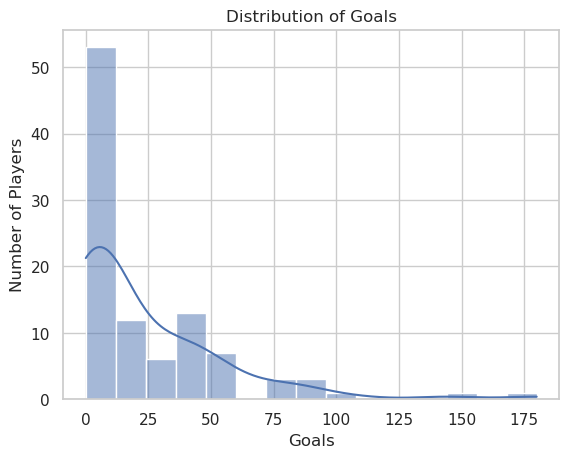

In [82]:
#3-goal distribution

sns.histplot(forwards['Goals'], bins=15, kde=True)
plt.title('Distribution of Goals')
plt.xlabel('Goals')
plt.ylabel('Number of Players')

plt.show()

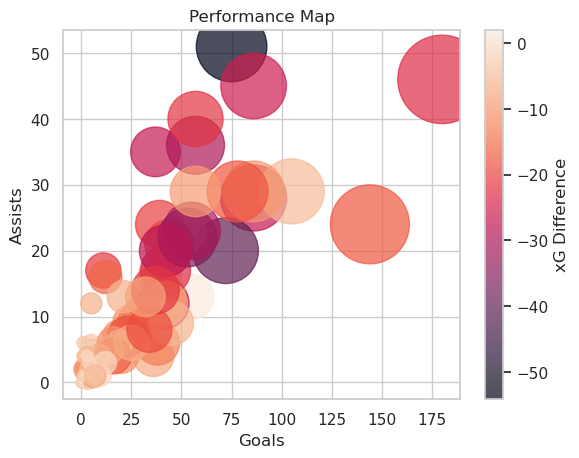

In [83]:
plt.figure()

scatter = plt.scatter(
    forwards['Goals'],
    forwards['Assists'],
    c=forwards['xG_diff'],  
    s=forwards['xG_estimated'] * 20,
    alpha=0.7
)

plt.colorbar(scatter, label='xG Difference')

plt.xlabel('Goals')
plt.ylabel('Assists')
plt.title('Performance Map')

plt.show()

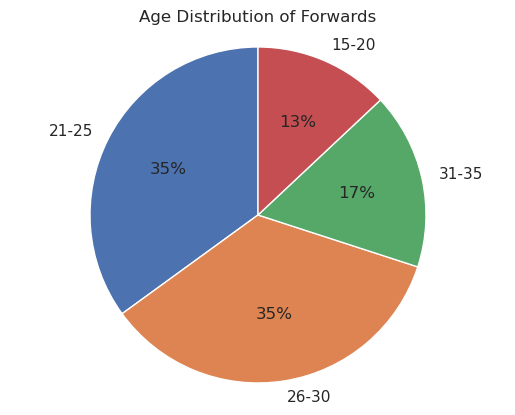

In [84]:
#pie chart for age (precntage of players in each age group)
age_counts = forwards['Age Group'].value_counts()
plt.figure()

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct='%1.0f%%',
    startangle=90
)

plt.title('Age Distribution of Forwards')
plt.axis('equal') 

plt.show()

In [85]:
#data cleaning for midfielders
#filtering midfielders with at least 1 appearance
midfielders = df_analysis[df_analysis['Position'].str.contains('Midfielder')&(df_analysis['Appearances'] > 0)]
# Drop the specified columns from the midfielders DataFrame
cols_to_drop_midfielder = [
    'Clean sheets','Goals conceded','Tackles','Tackle success %','Last man tackles',
    'Blocked shots','Interceptions','Clearances','Headed Clearance','Clearances off line',
    'Recoveries','Duels won','Duels lost','Successful 50/50s','Aerial battles won','Aerial battles lost',
    'Own goals','Errors leading to goal','Saves','Penalties saved','Punches','High Claims','Catches',
    'Sweeper clearances','Throw outs','Goal Kicks'
]

midfielders = midfielders.drop(columns=cols_to_drop_midfielder)
midfielders.describe()

#feature engineering for midfielders
midfielders['passes_per_match'] = midfielders['Passes'] / midfielders['Appearances']
midfielders['assists_per_match'] = midfielders['Assists'] / midfielders['Appearances']
midfielders['big_chances_created_per_match'] = midfielders['Big chances created'] / midfielders['Appearances']
midfielders['shots_per_match'] = midfielders['Shots'] / midfielders['Appearances']

midfielders['shot_conversion'] = np.where(
    midfielders['Shots'] > 0,
    midfielders['Goals'] / midfielders['Shots'],
    np.nan
)

midfielders['goals_per_shot_on_target'] = np.where(
    midfielders['Shots on target'] > 0,
    midfielders['Goals'] / midfielders['Shots on target'],
    np.nan
)
midfielders.describe()


,Jersey Number,Age,Appearances,Wins,Losses,Goals,Goals per match,Headed goals,Goals with right foot,Goals with left foot,...,Yellow cards,Red cards,Fouls,Offsides,passes_per_match,assists_per_match,big_chances_created_per_match,shots_per_match,shot_conversion,goals_per_shot_on_target
count,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,...,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,176.000000,163.000000,152.000000
mean,18.000000,25.982955,80.431818,33.414773,28.267045,7.414773,3.779318,0.619318,4.357955,2.352273,...,10.698864,0.357955,70.954545,7.125000,32.096434,0.082843,0.105720,0.912673,0.088720,0.259421
std,11.243792,3.754577,85.950789,40.551535,30.088104,11.057440,9.764815,1.342693,7.630184,5.047296,...,13.363712,0.822709,85.076961,13.344073,16.429493,0.094211,0.119365,0.584100,0.141063,0.209156
min,3.000000,17.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.333333,0.000000,0.000000,0.000000,0.000000,0.000000
25%,9.500000,23.000000,19.000000,6.000000,7.000000,0.000000,0.050000,0.000000,0.000000,0.000000,...,1.000000,0.000000,11.500000,0.000000,20.831897,0.012712,0.018230,0.517410,0.026486,0.165000
50%,16.500000,26.000000,46.500000,18.500000,18.000000,3.000000,0.120000,0.000000,1.000000,1.000000,...,6.000000,0.000000,38.500000,2.000000,29.509023,0.062500,0.079002,0.861992,0.065672,0.233589
75%,23.000000,29.000000,121.250000,46.000000,39.500000,9.250000,1.000000,1.000000,5.250000,2.000000,...,15.000000,0.000000,98.750000,7.250000,43.505765,0.113306,0.156661,1.237959,0.101915,0.333333
max,69.000000,35.000000,539.000000,272.000000,158.000000,61.000000,57.000000,9.000000,45.000000,42.000000,...,81.000000,5.000000,438.000000,102.000000,82.000000,0.500000,1.000000,3.133333,1.000000,1.000000


In [86]:
#data visualization for midfielders

In [87]:
#data cleaning for defenders
#filtering defenders with at least 1 appearance
defenders = df_analysis[df_analysis['Position'].str.contains('Defender')&(df_analysis['Appearances'] > 0)]
# Drop the specified columns from the defenders DataFrame
cols_to_drop_defender = [
    'Goals','Goals per match','Headed goals','Goals with right foot','Goals with left foot',
    'Penalties scored','Freekicks scored','Shots','Shots on target','Shooting accuracy %',
    'Hit woodwork','Big chances missed','Assists','Passes','Passes per match',
    'Big chances created','Crosses','Cross accuracy %','Through balls','Accurate long balls'
]

defenders = defenders.drop(columns=cols_to_drop_defender)

#feature engineering 
defenders['tackle_success_rate'] = np.where(
    defenders['Tackles'] > 0,
    defenders['Tackle success %'] / 100,
    np.nan
)

defenders['aerial_duel_success'] = np.where(
    (defenders['Aerial battles won'] + defenders['Aerial battles lost']) > 0,
    defenders['Aerial battles won'] / (defenders['Aerial battles won'] + defenders['Aerial battles lost']),
    np.nan
)

defenders['clearances_per_match'] = defenders['Clearances'] / defenders['Appearances']
defenders['duel_success_rate'] = np.where(
    (defenders['Duels won'] + defenders['Duels lost']) > 0,
    defenders['Duels won'] / (defenders['Duels won'] + defenders['Duels lost']),
    np.nan
)

defenders['errors_per_match'] = defenders['Errors leading to goal'] / defenders['Appearances']

defenders.describe()

,Jersey Number,Age,Appearances,Wins,Losses,Clean sheets,Goals conceded,Tackles,Tackle success %,Last man tackles,...,Goal Kicks,Yellow cards,Red cards,Fouls,Offsides,tackle_success_rate,aerial_duel_success,clearances_per_match,duel_success_rate,errors_per_match
count,156.000000,156.000000,156.000000,156.000000,156.00000,156.000000,156.000000,156.000000,156.000000,153.000000,...,0.0,156.000000,156.000000,156.000000,156.000000,152.000000,154.000000,156.000000,156.000000,156.000000
mean,16.153846,26.525641,83.634615,35.647436,28.50641,21.121795,96.756410,142.653846,62.576923,1.588235,...,NaN,11.730769,0.416667,65.083333,3.737179,0.642237,0.560300,3.525111,0.576400,0.015530
std,13.489855,4.064716,82.271783,38.640912,29.05734,23.602171,96.508758,154.891706,18.134991,3.221085,...,NaN,12.937241,0.744514,68.540919,5.220446,0.152029,0.144994,1.873310,0.092784,0.022942
min,2.000000,18.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,...,NaN,0.000000,0.000000,0.000000,0.000000,0.010000,0.000000,0.000000,0.125000,0.000000
25%,4.000000,23.000000,19.500000,7.000000,6.00000,2.750000,20.500000,31.500000,58.000000,0.000000,...,NaN,3.000000,0.000000,15.000000,0.000000,0.590000,0.502866,2.135638,0.536937,0.000000
50%,15.000000,26.000000,56.000000,23.500000,19.00000,12.000000,59.500000,89.500000,66.000000,0.000000,...,NaN,7.000000,0.000000,40.500000,2.000000,0.660000,0.571429,3.137500,0.580178,0.009648
75%,24.000000,30.000000,139.250000,50.500000,42.25000,31.000000,155.000000,204.500000,71.250000,2.000000,...,NaN,16.250000,1.000000,88.000000,5.000000,0.720000,0.625910,4.738281,0.623089,0.022859
max,76.000000,38.000000,374.000000,183.000000,130.00000,107.000000,452.000000,728.000000,100.000000,24.000000,...,NaN,78.000000,3.000000,327.000000,29.000000,1.000000,1.000000,11.000000,1.000000,0.166667


In [88]:
#data visualization for defenders

In [89]:
#data cleaning for goalkeepers
#filtering goalkeepers with at least 1 appearance
goalkeepers = df_analysis[df_analysis['Position'].str.contains('Goalkeeper')&(df_analysis['Appearances'] > 0)]
# Drop the specified columns from the goalkeepers DataFrame
cols_to_drop_goalkeeper = [
    'Goals','Goals per match','Headed goals','Goals with right foot','Goals with left foot',
    'Penalties scored','Freekicks scored','Shots','Shots on target','Shooting accuracy %',
    'Hit woodwork','Big chances missed','Assists','Passes','Passes per match',
    'Big chances created','Crosses','Cross accuracy %','Through balls','Accurate long balls',
    'Tackles','Tackle success %','Last man tackles','Blocked shots','Interceptions','Clearances',
    'Headed Clearance','Clearances off line','Recoveries','Duels won','Duels lost','Successful 50/50s',
    'Aerial battles won','Aerial battles lost','Own goals','Errors leading to goal','Offsides'
]

goalkeepers = goalkeepers.drop(columns=cols_to_drop_goalkeeper)


#feature engineering 
goalkeepers['save_percentage'] = np.where(
    (goalkeepers['Saves'] + goalkeepers['Goals conceded']) > 0,
    goalkeepers['Saves'] / (goalkeepers['Saves'] + goalkeepers['Goals conceded']),
    np.nan
)

goalkeepers['clean_sheets_per_match'] = goalkeepers['Clean sheets'] / goalkeepers['Appearances']
goalkeepers['goals_conceded_per_match'] = goalkeepers['Goals conceded'] / goalkeepers['Appearances']

goalkeepers['punches_high_claims_per_match'] = (goalkeepers['Punches'] + goalkeepers['High Claims']) / goalkeepers['Appearances']

goalkeepers['penalty_save_rate'] = np.where(
    goalkeepers['Penalties saved'] > 0,
    goalkeepers['Penalties saved'] / goalkeepers['Penalties saved'],  # لو عندك عدد penalties faced replace accordingly
    np.nan
)
goalkeepers.describe()

,Jersey Number,Age,Appearances,Wins,Losses,Clean sheets,Goals conceded,Saves,Penalties saved,Punches,...,Throw outs,Goal Kicks,Yellow cards,Red cards,Fouls,save_percentage,clean_sheets_per_match,goals_conceded_per_match,punches_high_claims_per_match,penalty_save_rate
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,...,45.000000,45.000000,45.000000,45.000000,45.000000,44.000000,45.000000,45.000000,45.000000,33.0
mean,16.022222,29.888889,78.777778,33.111111,27.511111,23.355556,100.844444,228.533333,1.666667,37.333333,...,319.466667,628.333333,2.222222,0.155556,1.022222,0.668718,0.248059,1.481941,1.082238,1.0
std,13.698853,3.675609,86.098223,43.234152,28.938510,29.193832,105.977690,252.964029,1.745123,53.179371,...,371.130497,706.129978,2.695863,0.424026,1.658160,0.093946,0.167276,0.789382,0.565404,0.0
min,1.000000,22.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.400000,0.000000,0.000000,0.000000,1.0
25%,1.000000,27.000000,7.000000,4.000000,4.000000,5.000000,12.000000,20.000000,0.000000,2.000000,...,39.000000,53.000000,0.000000,0.000000,0.000000,0.665584,0.177083,1.112150,0.666667,1.0
50%,13.000000,30.000000,57.000000,19.000000,16.000000,14.000000,65.000000,137.000000,1.000000,17.000000,...,200.000000,388.000000,1.000000,0.000000,0.000000,0.686167,0.250000,1.329545,1.060606,1.0
75%,26.000000,33.000000,112.000000,44.000000,44.000000,30.000000,166.000000,340.000000,2.000000,43.000000,...,484.000000,956.000000,3.000000,0.000000,1.000000,0.717883,0.345794,1.662983,1.500000,1.0
max,49.000000,38.000000,340.000000,174.000000,104.000000,127.000000,383.000000,941.000000,7.000000,269.000000,...,1516.000000,2806.000000,11.000000,2.000000,6.000000,0.909091,0.857143,4.000000,2.081301,1.0


In [90]:
#data visualization for midfielders